In [37]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import datetime
from bs4 import BeautifulSoup
import requests
import re
# Load OffSetImage
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Create Date and Time Strings for use in plots
# String of current Eastern Time Zone in HH:MM format (example: 15:00)
now = datetime.datetime.now()
time = now.strftime("%H:%M")

####### SET MANUAL TIME IF NEED BE #######
# time = '15:00'

anno_font_size_1 = '20'
anno_font_size_2 = '16'

# Date in MM/DD/YYYY Format
date = now.strftime("%m/%d/%Y")
# string of date with no slashes for use in file names
date_string = now.strftime("%m%d%Y")

### Set Default Plot Ratio and Size
set_fig_size = (8, 10) # Good Ratio for Reddit - Insta - mobile

# path to temp image folder
conf_race_path = os.path.join('..', '..', 'TEMP', 'IMAGES', 'conference_race')
if not os.path.exists(conf_race_path):
    os.makedirs(conf_race_path)

##############################################


In [38]:
import config
from pathlib import Path

# ======= BASE PATHS =======
try:
    # Works when running as a script
    base_dir = Path(__file__).resolve().parent
except NameError:
    # Fallback for notebooks or interactive mode
    base_dir = Path.cwd()

# one directory up (your config.py lives here)
config_folder = base_dir.parent

# two directories up (for TEMP, data, images)
project_root = base_dir.parent.parent



# ======= DATA FOLDERS =======
temp_folder = project_root / "TEMP"
data_folder = project_root / "data"
roster_folder = data_folder / "player_info"
school_info_folder = data_folder / "school_info"

# ======= IMAGE FOLDERS =======
img_folder = project_root / "images"
logo_folder = img_folder / "logos"
background_folder = img_folder / "background"
plot_folder = project_root / "TEMP" / "IMAGE" / "scatter_plots"

background_img_path2 = background_folder / "main1.png"


# ============================
school_info_file = school_info_folder / "arena_school_info.csv"
school_info_df = pd.read_csv(school_info_file)

# ======= IMPORT CONFIG =======
sys.path.insert(0, str(config_folder))
import config  # now you can import config.py

### Link to Config / DB / ECct

In [39]:
# import config_team_info

# print(config_team_info)

# print(config_team_info.conference_teams)
import config

# Create vatiable for a list of conference names
conf_name = list(config.conference_teams.keys())

print(config.conference_teams)
print(config.team_color_mapping)

{'Atlantic': ['Air Force', 'Army', 'Bentley', 'Canisius', 'Holy Cross', 'Mercyhurst', 'Niagara', 'RIT', 'Robert Morris', 'Sacred Heart'], 'Big Ten': ['Michigan', 'Michigan State', 'Minnesota', 'Notre Dame', 'Ohio State', 'Penn State', 'Wisconsin'], 'CCHA': ['Augustana', 'Bemidji State', 'Bowling Green', 'Ferris State', 'Lake Superior', 'Michigan Tech', 'Minnesota State', 'Northern Michigan', 'St Thomas'], 'ECAC': ['Brown', 'Clarkson', 'Colgate', 'Cornell', 'Dartmouth', 'Harvard', 'Princeton', 'Quinnipiac', 'Rensselaer', 'St Lawrence', 'Union', 'Yale'], 'Hockey East': ['Boston College', 'Boston University', 'Connecticut', 'Maine', 'Massachusetts', 'Mass Lowell', 'Merrimack', 'New Hampshire', 'Northeastern', 'Providence', 'Vermont'], 'NCHC': ['Arizona State', 'Colorado College', 'Denver', 'Miami', 'Minnesota Duluth', 'North Dakota', 'Omaha', 'St Cloud State', 'Western Michigan'], 'Independents': ['Alaska Anchorage', 'Alaska', 'Lindenwood', 'Long Island', 'Stonehill'], 'NCAA D1': ['Air Fo

#### Logos - mapping and helper function

In [40]:
### create logo_mapping 
logo_mapping = school_info_df.set_index('Team')['logo_abv'].to_dict()
logo_mapping # Check the dictionary

{'Air Force': 'afa',
 'Alaska': 'akf',
 'Alaska Anchorage': 'aka',
 'American Intl': 'aic',
 "American Int'l": 'aic',
 'Arizona State': 'asu',
 'Army': 'arm',
 'Augustana': 'aug',
 'Bemidji State': 'bmj',
 'Bentley': 'ben',
 'Boston College': 'bc_',
 'Boston University': 'bu_',
 'Bowling Green': 'bgs',
 'Brown': 'brn',
 'Canisius': 'cns',
 'Clarkson': 'clk',
 'Colgate': 'clg',
 'Colorado College': 'cc_',
 'Connecticut': '_con',
 'Cornell': 'cor',
 'Dartmouth': 'dar',
 'Denver': 'den',
 'Ferris State': 'fsu',
 'Harvard': 'har',
 'Holy Cross': 'hcr',
 'Lake Superior': 'lss',
 'Lindenwood': 'lin',
 'Long Island': 'liu',
 'Maine': 'mne',
 'Mass Lowell': 'uml',
 'Mass. Lowell': 'uml',
 'Massachusetts': 'uma',
 'Mercyhurst': 'mrc',
 'Merrimack': 'mer',
 'Miami': 'mia',
 'Michigan': 'mic',
 'Michigan State': 'msu',
 'Michigan Tech': 'mtu',
 'Minnesota': 'min',
 'Minnesota Duluth': 'mnd',
 'Minnesota State': 'mns',
 'New Hampshire': 'unh',
 'Niagara': 'nia',
 'North Dakota': 'ndk',
 'Northeast

In [41]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def add_logos_to_plot(
    data_df,
    x_col,
    y_col,
    logo_mapping,
    logo_folder,
    ax,
    teams_in_region,
    zoom=0.17,
    greyed_teams=None,          # NEW
    grey_alpha=0.28,            # NEW (how faded)
    grey_saturation=0.0,        # NEW (0 = true grayscale, 0.15 = slight color retained)
):
    """
    Places team logos at terminal points. Optionally greys out some teams.
    """
    logo_folder = Path(logo_folder)
    greyed_teams = set(greyed_teams or [])

    for team in teams_in_region:
        team_data = data_df[data_df["Team"] == team]
        if team_data.empty:
            continue

        last_row = team_data.iloc[-1]
        x = last_row[x_col]
        y = last_row[y_col]

        logo_file = logo_mapping.get(team, "")
        if not logo_file:
            continue

        logo_path = logo_folder / f"{logo_file}.png"
        if not logo_path.exists():
            continue

        try:
            logo_img = plt.imread(str(logo_path))

            # --- Grey-out effect (desaturate + fade) ---
            if team in greyed_teams:
                # Convert to luminance while keeping alpha if present
                if logo_img.ndim == 3 and logo_img.shape[2] in (3, 4):
                    rgb = logo_img[..., :3]
                    lum = (0.2126 * rgb[..., 0] + 0.7152 * rgb[..., 1] + 0.0722 * rgb[..., 2])
                    grey_rgb = np.stack([lum, lum, lum], axis=-1)

                    # Optionally retain a tiny bit of original color
                    if grey_saturation > 0:
                        grey_rgb = (1 - grey_saturation) * grey_rgb + grey_saturation * rgb

                    if logo_img.shape[2] == 4:
                        a = logo_img[..., 3:4]
                        logo_img = np.concatenate([grey_rgb, a], axis=-1)
                    else:
                        logo_img = grey_rgb

                imagebox = OffsetImage(logo_img, zoom=zoom)
                imagebox.set_alpha(grey_alpha)
            else:
                imagebox = OffsetImage(logo_img, zoom=zoom)

            ab = AnnotationBbox(
                imagebox,
                (x, y),
                frameon=False,
                xybox=(0, 0),
                boxcoords="offset points",
                pad=0,
                zorder=4,
            )
            ax.add_artist(ab)

        except Exception as e:
            print(f"Error adding logo for {team}: {e}")

#### Connect to DB for game_details table

In [42]:
## Connect to database using the recent_clean_db path from config.py
import sqlite3

### CONFIG FILE NOT WORKING AS EXPECTED - MANUAL FIX ####
data_folder = ('../../data/db/')
# filename = '2025_Feb_13_CLEAN.db'
filename = 'Season_YTD.db'
recent_clean_db = data_folder + filename
########### END MANUAL FIX ###########

conn = sqlite3.connect(recent_clean_db)
cursor = conn.cursor()
print("Connected to database:", config.recent_clean_db)

### Select the game_details table and store it as a dataframe 
game_details_df = pd.read_sql_query("SELECT * FROM game_details", conn)

## Remove any Periods from the Game_ID column and replace with ""
game_details_df['Game_ID'] = game_details_df['Game_ID'].str.replace('.', '', regex=False)

print("Loaded game_details table with shape:", game_details_df.shape)


Connected to database: ../../data/db/Season_YTD.db
Loaded game_details table with shape: (954, 13)


### Get Current Men's Results Table form CHN

In [43]:
### USE Results Scraper code from other notebook to get up to date data
## Functions
### Parse the current season schedule / results page
############ USE WEB SCRAPING TO GET RESULTS TABLE ############
current_year_url = 'https://www.collegehockeynews.com/schedules/?season=20252026'

def parse_current_season(url):
        # Initialize variables
    current_date = None
    current_conference = None
    game_notes = None

    # Initialize an empty list to hold the data
    data = []

    # Parse the page with BeautifulSoup
    # Get the page with requests
    response = requests.get(url)

    # Create a BeautifulSoup object
    soup = BeautifulSoup(response.text, 'html.parser')

    # select the table or tables
    tables = soup.find_all('table')

    rows = soup.find_all('tr')

    # Loop through each row to find relevant information
    for row in rows:
        # Check for date row
        if row.get('class') == ['stats-section']:
            current_date = row.find('td').text.strip()
        # Check for conference row
        elif row.get('class') == ['sked-header']:
            current_conference = row.find('td').text.strip()
        # Check for game notes
        elif len(row.find_all('td')) == 2:
            game_notes = row.find_all('td')[1].text.strip()
        # Process rows with game data
        elif row.get('valign') == 'top':
            cells = row.find_all('td')
            if len(cells) >= 9:
                home_team = cells[0].text.strip()
                # Remove any hyphens from the team name
                home_team = home_team.replace('-', ' ')
                home_team_link = cells[0].find('a')['href'] if cells[0].find('a') else None
                home_score = cells[1].text.strip()
                away_team = cells[3].text.strip()
                away_team_link = cells[3].find('a')['href'] if cells[3].find('a') else None
                away_score = cells[4].text.strip()
                ot = cells[5].text.strip()
                box_link = cells[7].find('a')['href'] if cells[7].find('a') else None
                metrics_link = cells[8].find('a')['href'] if cells[8].find('a') else None
                # Capture Game Notes
                game_notes_cell = cells[-1].find('small')
                game_notes = game_notes_cell.text.strip() if game_notes_cell else None

                # Append data to the list
                data.append([current_date, current_conference, game_notes, home_team, home_team_link, home_score, away_team, away_team_link, away_score, ot, box_link, metrics_link])
                game_notes = None  # Reset game notes for the next row
    return data

## call the function
data = parse_current_season(current_year_url)


# Create a dataframe from the list

columns = ['Date', 'Conference', 'Game_Notes',  'Away_Team', 'Away_Team_Link', 'Away_Score', 'Home_Team', 'Home_Team_Link', 'Home_Score', 'OT', 'Box_Link', 'Metrics_Link']
df = pd.DataFrame(data, columns=columns)
            
## Extract the day of the week from the date and save in new column
df['Day'] = pd.to_datetime(df['Date']).dt.day_name()
# remove day of the week from date
# format data column as YYYY-MM-DD
df['Date'] = pd.to_datetime(df['Date']).dt.strftime('%Y-%m-%d')

### Create a new column for the game ID
## Game ID will be a combination of the date and abbreviated team names

# Loop to abbreviate the team names
for row in df.itertuples():
    home_team = row.Home_Team
    away_team = row.Away_Team
    home_team_abbr = home_team.split(' ')[-1]
    away_team_abbr = away_team.split(' ')[-1]
    # Remove any hyphens from the team name if there are any
    home_team_abbr = home_team_abbr.replace('-', ' ')
    away_team_abbr = away_team_abbr.replace('-', ' ')
    game_id = f'{row.Date}-{home_team_abbr}-{away_team_abbr}'
    df.loc[row.Index, 'Game_ID'] = game_id

# Create a new column for the game ID
df['Game_ID'] = df['Game_ID'].str.replace(',', '')

# Remove any hyphens from the team names if any
df['Home_Team'] = df['Home_Team'].str.replace('-', ' ')
df['Away_Team'] = df['Away_Team'].str.replace('-', ' ')

# Remove any Punctuation from Team Names
df['Home_Team'] = df['Home_Team'].str.replace(r'[^\w\s]', '', regex=True)
df['Away_Team'] = df['Away_Team'].str.replace(r'[^\w\s]', '', regex=True)

# Apply the function to the DataFrame
df['Game_ID'] = df.apply(lambda row: f'{row.Date}-{row.Away_Team}-{row.Home_Team}', axis=1)

############ Team Name Fixes ############
## Replace 'RPI' with 'Rensselaer'
df['Home_Team'] = df['Home_Team'].replace('RPI', 'Rensselaer')
df['Away_Team'] = df['Away_Team'].replace('RPI', 'Rensselaer')


##############################################

#### Store a copy of the full schedule dataframe before filtering
full_schedule_df = df.copy()

# Rename to schedule_df to put into next block
schedule_df = df


In [44]:
import pandas as pd
import numpy as np
import re

def compute_conference_schedule_counts(
    schedule_df: pd.DataFrame,
    conf_list=None,
    conference_col: str = "Conference",
    game_id_col: str = "Game_ID",
    home_col: str = "Home_Team",
    away_col: str = "Away_Team",
):
    """
    Robustly compute scheduled conference games per team from the *full schedule*.

    Returns:
      team_conf_counts: rows (Conference, Team, Conf_Games_Scheduled)
      conf_games_scheduled: dict {Conference: games_scheduled_per_team}  (mode per conference)
      mismatches: teams whose counts != expected for that conference
      unknown_conference_labels: value_counts() of labels we couldn't map to a real conference
    """

    if conf_list is None:
        conf_list = ["Atlantic", "Big Ten", "CCHA", "ECAC", "Hockey East", "NCHC"]

    # --- Basic required columns ---
    required = [conference_col, game_id_col, home_col, away_col]
    missing = [c for c in required if c not in schedule_df.columns]
    if missing:
        raise ValueError(f"schedule_df missing required columns: {missing}")

    df = schedule_df.copy()

    # --- Canonicalize conference labels ---
    # Handles things like "Hockey East Game", "Atlantic Hockey", "Big Ten Game", etc.
    def _clean_conf(val: str) -> str:
        if pd.isna(val):
            return ""
        s = str(val).strip()

        # normalize common variants
        s = s.replace("Atlantic Hockey", "Atlantic")
        s = s.replace("Atlantic Hockey Association", "Atlantic")

        # remove trailing "Game"/"Games"
        s = re.sub(r"\s+Game(s)?\b", "", s, flags=re.IGNORECASE).strip()

        # if the string contains a known conference name anywhere, return that canonical name
        for c in conf_list:
            if re.search(rf"\b{re.escape(c)}\b", s, flags=re.IGNORECASE):
                return c

        return s

    df["Conference_Clean"] = df[conference_col].apply(_clean_conf)

    # Keep only rows that map to our real conferences
    conf_df = df[df["Conference_Clean"].isin(conf_list)].copy()

    # Drop unusable rows
    conf_df = conf_df.dropna(subset=[game_id_col, home_col, away_col])
    conf_df = conf_df[conf_df[game_id_col].astype(str).str.strip() != ""]

    # --- Make one row per team per game (each game counts once for each team) ---
    long = pd.concat(
        [
            conf_df[["Conference_Clean", game_id_col, home_col]].rename(columns={home_col: "Team"}),
            conf_df[["Conference_Clean", game_id_col, away_col]].rename(columns={away_col: "Team"}),
        ],
        ignore_index=True,
    ).rename(columns={"Conference_Clean": "Conference"})

    # Defensive cleanup
    long["Team"] = long["Team"].astype(str).str.strip()
    long = long[long["Team"] != ""]

    # Count unique conference games per team
    team_conf_counts = (
        long.groupby(["Conference", "Team"], as_index=False)[game_id_col]
            .nunique()
            .rename(columns={game_id_col: "Conf_Games_Scheduled"})
            .sort_values(["Conference", "Conf_Games_Scheduled", "Team"], ascending=[True, False, True])
    )

    # Expected games per team for each conference (mode is safest)
    conf_expected = (
        team_conf_counts.groupby("Conference")["Conf_Games_Scheduled"]
        .agg(lambda s: int(s.mode().iloc[0]) if not s.mode().empty else int(s.max()))
    )
    conf_games_scheduled = conf_expected.to_dict()

    # Flag mismatches
    team_conf_counts["Expected_Conf_Games"] = team_conf_counts["Conference"].map(conf_games_scheduled)
    mismatches = team_conf_counts[team_conf_counts["Conf_Games_Scheduled"] != team_conf_counts["Expected_Conf_Games"]].copy()

    # Labels we *didn't* map (useful debug)
    unknown_conference_labels = (
        df.loc[~df["Conference_Clean"].isin(conf_list), conference_col]
          .fillna("")
          .astype(str)
          .str.strip()
          .value_counts()
    )

    return team_conf_counts, conf_games_scheduled, mismatches, unknown_conference_labels

In [45]:
# schedule_df

In [46]:
schedule_df['Conference'].value_counts()

Conference
Non-Conference                                                                          315
Hockey East                                                                             132
ECAC                                                                                    132
Atlantic Hockey                                                                         130
CCHA                                                                                    117
NCHC                                                                                    108
Big Ten                                                                                  84
Exhibition                                                                               60
Holiday Face-Off (at Fiserv Forum, Milwaukee, Wis.)                                       4
Beanpot (at TD Garden, Boston, Mass.)                                                     4
Connecticut Ice Tournament (at Ingalls Rink, New Haven, Conn.)       

#### Check the Schedule

In [47]:
## ===== PATCH === ##
## Addresses Conference Label Issues in the scraped schedule data - 
import re


CANON_CONFS = ["Atlantic", "Big Ten", "CCHA", "ECAC", "Hockey East", "NCHC"]

def clean_conference_label(x: str) -> str:
    if pd.isna(x):
        return ""
    s = str(x).strip()

    # Common CHN-ish variants
    s = re.sub(r"\s+Game(s)?\b", "", s, flags=re.IGNORECASE).strip()     # "Hockey East Game" -> "Hockey East"
    s = s.replace("Atlantic Hockey", "Atlantic").strip()                # normalize to your canonical name

    # If something still contains a known conference name, extract it
    for c in CANON_CONFS:
        if re.search(rf"\b{re.escape(c)}\b", s, flags=re.IGNORECASE):
            return c

    return s

In [48]:
team_conf_counts, conf_games_scheduled, mismatches, unknown_labels = compute_conference_schedule_counts(full_schedule_df)

print(conf_games_scheduled)

if not mismatches.empty:
    display(mismatches)

# Debug: see what conference strings are still floating around
display(unknown_labels.head(25))

{'Atlantic': 26, 'Big Ten': 24, 'CCHA': 26, 'ECAC': 22, 'Hockey East': 24, 'NCHC': 24}


,Conference,Team,Conf_Games_Scheduled,Expected_Conf_Games
16,Big Ten,TBDbt,1,24
27,CCHA,TBDcc,1,26
38,ECAC,TBDec,1,22
39,ECAC,TBDec1,1,22
40,ECAC,TBDec2,1,22
41,ECAC,TBDec3,1,22
42,ECAC,TBDec4,1,22
64,NCHC,TBDnt,1,24


Conference
Non-Conference                                                                          315
Exhibition                                                                               60
Holiday Face-Off (at Fiserv Forum, Milwaukee, Wis.)                                       4
Beanpot (at TD Garden, Boston, Mass.)                                                     4
Connecticut Ice Tournament (at Ingalls Rink, New Haven, Conn.)                            4
Desert Hockey Classic (at Mullett Arena, Tempe, Ariz.)                                    4
Cactus Cup (at Acrisure Arena, Palm Springs, Calif.)                                      4
Great Lakes Invitational (at Van Andel Arena, Grand Rapids, Mich.)                        4
Adirondack Winter Invitational (at 1980 Rink Herb Brooks Arena, Lake Placid, N.Y.)        4
Friendship Four (at SSE Arena, Belfast, N. Ireland)                                       4
Ice Breaker (at Mullett Arena, Tempe, Ariz.)                         

In [49]:
# schedule_for_counts = full_schedule_df.copy()
# schedule_for_counts["Conference"] = schedule_for_counts["Conference"].apply(clean_conference_label)

# # IMPORTANT: define conference games based on cleaned labels
# schedule_for_counts["Is_Conference_Game"] = schedule_for_counts["Conference"].isin(CANON_CONFS)

# team_conf_counts, conf_games_scheduled, mismatches = compute_conference_schedule_counts(schedule_for_counts)

# print(conf_games_scheduled)
# display(mismatches.head(20))

In [50]:
# import pandas as pd

# # schedule_df is already loaded with completed + uncompleted games
# # Normalize conference labels
# schedule_df["Conference"] = schedule_df["Conference"].fillna("").str.strip()

# Your 6 real conferences
real_conferences = {
    "Atlantic",
    "Big Ten",
    "CCHA",
    "ECAC",
    "Hockey East",
    "NCHC",
}

# Identify conference games (by game type)
schedule_df["Is_Conference_Game"] = schedule_df["Conference"].isin(real_conferences)

# Determine if game is completed
schedule_df["Completed"] = (
    schedule_df["Home_Score"].notna()
    & schedule_df["Away_Score"].notna()
)

# Long form: one row per *team* per game
home_games = schedule_df.assign(
    Team=schedule_df["Home_Team"],
    Opponent=schedule_df["Away_Team"],
)

away_games = schedule_df.assign(
    Team=schedule_df["Away_Team"],
    Opponent=schedule_df["Home_Team"],
)

long_df = pd.concat([home_games, away_games], ignore_index=True)


In [51]:
# schedule_df

In [52]:
conf_schedule = schedule_df[
    schedule_df["Conference"].isin(["Atlantic Hockey", "Big Ten", "CCHA", 
            "ECAC", "Hockey East", "NCHC"])
].copy()
print("Filtered conference schedule shape:", conf_schedule.shape)

Filtered conference schedule shape: (703, 16)


In [53]:
# conf_schedule

In [54]:
import re

game_details_df["Shootout_Winner"] = game_details_df["Details"].str.extract(
    r"^(.*?)\s+won shootout", expand=False
).str.strip()

# Merge the shootout winner info into conf_schedule
conf_schedule = conf_schedule.merge(
    game_details_df[["Game_ID", "Shootout_Winner"]],
    on="Game_ID",
    how="left"
)

# Treat empty / whitespace-only strings as missing (i.e., no OT)
conf_schedule["OT"] = conf_schedule["OT"].replace(r"^\s*$", pd.NA, regex=True)

conf_schedule = conf_schedule[conf_schedule["Completed"]].copy()


# game_details_df

In [55]:
# conf_schedule.info()
# game_details_df.info()

# # Filter down to only game with Shootout_Winner not null
# shootout_games = game_details_df[game_details_df["Shootout_Winner"].
# notnull()].copy()
# print("Filtered shootout games shape:", shootout_games.shape)

# shootout_games

In [56]:
# conf_schedule.shape
# conf_schedule

In [57]:
import pandas as pd

def compute_game_points(row):
    home = row["Home_Team"]
    away = row["Away_Team"]
    hs   = row["Home_Score"]
    as_  = row["Away_Score"]

    # 0) Skip clearly unplayed / bogus score rows
    if pd.isna(hs) or pd.isna(as_):
        return pd.Series({"Home_Points": pd.NA, "Away_Points": pd.NA})

    ot_val = row.get("OT")
    shootout_winner = row.get("Shootout_Winner")

    # Normalize OT: True only if non-empty
    if pd.isna(ot_val):
        ot_flag = False
    elif isinstance(ot_val, str):
        ot_flag = ot_val.strip() != ""   # "" or spaces → False
    else:
        ot_flag = True                   # any other non-null → treat as OT

    # ---- treat "scheduled but unplayed" games defensively ----
    # Pattern: 0-0 (or same score), no OT, no shootout winner
    if (hs == as_) and (not ot_flag) and (
        pd.isna(shootout_winner) or str(shootout_winner).strip() == ""
    ):
        # Clearly not a finished OT/SO game → treat as unplayed
        return pd.Series({"Home_Points": pd.NA, "Away_Points": pd.NA})

    def norm(name):
        return (str(name).lower()
                .replace('.', '')
                .replace('-', ' ')
                .replace('  ', ' ')
                .strip())

    # 1) Decide winner / loser
    if hs > as_:
        winner, loser = home, away
    elif as_ > hs:
        winner, loser = away, home
    else:
        # scores tied but game went past regulation (ot_flag True) and there is a shootout winner
        if pd.isna(shootout_winner) or str(shootout_winner).strip() == "":
            raise ValueError(f"No shootout winner for tied finished game {row['Game_ID']}")
        nh, na, nw = norm(home), norm(away), norm(shootout_winner)
        if nw == nh:
            winner, loser = home, away
        elif nw == na:
            winner, loser = away, home
        else:
            raise ValueError(
                f"Shootout winner '{shootout_winner}' does not match "
                f"teams '{home}' / '{away}' for game {row['Game_ID']}"
            )

    # 2) Regulation vs OT/SO?
    is_reg = (not ot_flag) and (hs != as_)   # reg = no OT flag & unequal scores
    if is_reg:
        w_pts, l_pts = 3, 0
    else:
        w_pts, l_pts = 2, 1

    return pd.Series({
        "Home_Points": w_pts if winner == home else l_pts,
        "Away_Points": w_pts if winner == away else l_pts,
    })


In [58]:
conf_schedule

# HOTFIX 2-21-26 Add Shootout Winner and OT info to conf_schedule for Wesstern Michigan Colorado College game
conf_schedule.loc[conf_schedule["Game_ID"] == "2026-02-20-Western Michigan-Colorado College", ["Shootout_Winner"]] = ["Western Michigan"]

In [59]:
# Apply scoring
points = conf_schedule.apply(compute_game_points, axis=1)
conf_schedule = pd.concat([conf_schedule, points], axis=1)

# Keep only games where we successfully assigned points
conf_schedule = conf_schedule.dropna(subset=["Home_Points", "Away_Points"]).copy()

print("Conference games with points:", conf_schedule.shape)


Conference games with points: (611, 19)


##### Sanity Check

In [60]:
print(conf_schedule["Home_Points"].value_counts())
print(conf_schedule["Away_Points"].value_counts())

# Crosstab OT vs points pattern
print(
    pd.crosstab(
        conf_schedule["OT"].fillna("reg"),
        [conf_schedule["Home_Points"], conf_schedule["Away_Points"]]
    )
)


Home_Points
3    252
0    242
2     64
1     53
Name: count, dtype: int64
Away_Points
0    252
3    242
1     64
2     53
Name: count, dtype: int64
Home_Points    0   1   2    3
Away_Points    3   2   1    0
OT                           
ot             0  53  64    0
reg          242   0   0  252


In [61]:
# ----- Build per-team game rows -----

home_df = conf_schedule.assign(
    Team       = conf_schedule["Home_Team"],
    Opponent   = conf_schedule["Away_Team"],
    Team_Score = conf_schedule["Home_Score"],
    Opp_Score  = conf_schedule["Away_Score"],
    Team_Points = conf_schedule["Home_Points"],
)[["Game_ID", "Date", "Conference", "Team", "Opponent", 
   "Team_Score", "Opp_Score", "Team_Points"]]

away_df = conf_schedule.assign(
    Team       = conf_schedule["Away_Team"],
    Opponent   = conf_schedule["Home_Team"],
    Team_Score = conf_schedule["Away_Score"],
    Opp_Score  = conf_schedule["Home_Score"],
    Team_Points = conf_schedule["Away_Points"],
)[["Game_ID", "Date", "Conference", "Team", "Opponent", 
   "Team_Score", "Opp_Score", "Team_Points"]]

team_games_df = pd.concat([home_df, away_df], ignore_index=True)


In [62]:
# team_games_df.head()
# team_games_df["Team_Points"].value_counts()


In [63]:
print("conf_name type:", type(conf_name))
print("conf_name value:", conf_name)


conf_name type: <class 'list'>
conf_name value: ['Atlantic', 'Big Ten', 'CCHA', 'ECAC', 'Hockey East', 'NCHC', 'Independents', 'NCAA D1']


In [64]:
conf_names = sorted(team_games_df["Conference"].unique())

results = {}

for conf_name in conf_names:
    conf_games = team_games_df[team_games_df["Conference"] == conf_name].copy()

    final_standings = (
        conf_games.groupby("Team", as_index=False)
        .agg(GP=("Game_ID", "count"), Points=("Team_Points", "sum"))
    )
    final_standings["Ppct"] = final_standings["Points"] / (3 * final_standings["GP"])
    league_avg_ppct = final_standings["Ppct"].mean()

    print(f"{conf_name}: league average P% = {league_avg_ppct:.3f}")

    results[conf_name] = {
        "final_standings": final_standings,
        "league_avg_ppct": league_avg_ppct,
    }


Atlantic Hockey: league average P% = 0.499
Big Ten: league average P% = 0.499
CCHA: league average P% = 0.499
ECAC: league average P% = 0.500
Hockey East: league average P% = 0.502
NCHC: league average P% = 0.500


In [65]:
team_games_df

,Game_ID,Date,Conference,Team,Opponent,Team_Score,Opp_Score,Team_Points
0,2025-10-03-Merrimack-Mass Lowell,2025-10-03,Hockey East,Mass Lowell,Merrimack,4,0,3
1,2025-10-10-Mass Lowell-Merrimack,2025-10-10,Hockey East,Merrimack,Mass Lowell,4,1,3
2,2025-10-10-Sacred Heart-RIT,2025-10-10,Atlantic Hockey,RIT,Sacred Heart,0,1,0
3,2025-10-11-Sacred Heart-RIT,2025-10-11,Atlantic Hockey,RIT,Sacred Heart,1,6,0
4,2025-10-14-Canisius-Army,2025-10-14,Atlantic Hockey,Army,Canisius,1,3,0
...,...,...,...,...,...,...,...,...
1217,2026-02-20-Providence-Vermont,2026-02-20,Hockey East,Providence,Vermont,5,2,3
1218,2026-02-20-Connecticut-Boston College,2026-02-20,Hockey East,Connecticut,Boston College,2,5,0
1219,2026-02-20-Lake Superior-Northern Michigan,2026-02-20,CCHA,Lake Superior,Northern Michigan,7,5,3
1220,2026-02-20-Augustana-St Thomas,2026-02-20,CCHA,Augustana,St Thomas,3,3,2


### Font Settings

In [66]:
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.image as mpimg

# Path to your custom font file
font_path = '../../data/Exo_2/Exo2-VariableFont_wght.ttf'
# Check if the font file exists and print confirmation
if os.path.isfile(font_path):
    print(f"Custom font file found: {font_path}")

# 2) Register font with Matplotlib's font manager
fm.fontManager.addfont(font_path)

# 3) Get the actual internal family name from the file
exo2_name = fm.FontProperties(fname=font_path).get_name()
print("Loaded font family:", exo2_name)  # e.g., "Exo 2"

# 4) Set as default (affects titles, labels, legends, text, ticks)
mpl.rcParams['font.family'] = exo2_name

# 5) Now your font dicts should NOT include `family` as a FontProperties.
#    Just use normal kwargs (size/weight/color). Family is handled globally.
font_title_param = {'size': 28, 'weight': 'normal', 'color': 'black'}
font_label_param = {'size': 22, 'weight': 'normal', 'color': 'black'}
# Quadrant font size will be set dynamically based on figure size
font_tick_size  = 16  # use tick_params, not a fontdict
quad_font_size = 28  # will set later based on figure size

Custom font file found: ../../data/Exo_2/Exo2-VariableFont_wght.ttf
Loaded font family: Exo 2


### Figure Size and other Global Settings

In [67]:
# schedule_df

In [68]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from pathlib import Path

def plot_conference_points_above_avg(
    ts_df: pd.DataFrame,
    conf_name: str,
    team_color_mapping: dict | None = None,
    logo_mapping: dict | None = None,
    logo_folder: str | None = None,
    highlight_teams: list[str] | None = None,
    background_img_path: str | None = None,
    logo_zoom: float = 0.12,
    figsize=(10, 6),
):
    """
    Plot 'points above league-average points pace' over conference games
    for one conference (3–2–1–0 system).
    """
    conf_ts = ts_df[ts_df["Conference"] == conf_name].copy()
    if conf_ts.empty:
        print(f"No data for conference {conf_name}")
        return None, None

    league_avg_ppct = conf_ts["League_Avg_Ppct"].iloc[0]
    league_avg_ppg = conf_ts["League_Avg_PPG"].iloc[0]

    max_gp = int(conf_ts["Team_Game_Number"].max())

    # Symmetric y-range around 0 in *points*
    ymin = conf_ts["Points_Above_League"].min()
    ymax = conf_ts["Points_Above_League"].max()
    y_lim = max(abs(ymin), abs(ymax))
    y_lim = np.ceil(y_lim)
    y_margin = 0.5
    y_min = -y_lim - y_margin
    y_max = y_lim + y_margin

    fig, ax = plt.subplots(figsize=figsize)

    # Background image (optional)
    if background_img_path is not None:
        bg_path = Path(background_img_path)
        if bg_path.exists():
            try:
                bg_img = plt.imread(str(bg_path))
                ax.imshow(
                    bg_img,
                    extent=(0, max_gp + 1, y_min, y_max),
                    aspect="auto",
                    zorder=0,
                )
                ax.set_facecolor("none")
            except Exception as e:
                print(f"Error loading background image: {e}")
        else:
            print(f"Background image not found at: {bg_path}")
    else:
        ax.set_facecolor("white")

    terminal_points = []

    # Lines
    for team, g in conf_ts.groupby("Team"):
        g = g.sort_values("Team_Game_Number")

        color = None
        if team_color_mapping is not None:
            raw = team_color_mapping.get(team)
            if isinstance(raw, (list, tuple)) and len(raw) > 0:
                color = raw[0]
            elif isinstance(raw, dict) and raw:
                color = raw.get("primary") or next(iter(raw.values()))
            else:
                color = raw

        is_highlight = highlight_teams is not None and team in highlight_teams
        lw = 2.5 if is_highlight else 1.3
        alpha = 1.0 if is_highlight else 0.8
        zorder = 3 if is_highlight else 2

        plot_kwargs = dict(
            linewidth=lw,
            alpha=alpha,
            zorder=zorder,
            label=team,
        )
        if color is not None:
            plot_kwargs["color"] = color

        ax.plot(
            g["Team_Game_Number"],
            g["Points_Above_League"],
            **plot_kwargs,
        )

        last_row = g.iloc[-1]
        terminal_points.append(
            {
                "Team": team,
                "x": last_row["Team_Game_Number"],
                "y": last_row["Points_Above_League"],
            }
        )

    # Limits
    ax.set_xlim(0, max_gp + 1)
    ax.set_ylim(y_min, y_max)

    # Ticks & grid
    ax.set_xticks(range(0, max_gp + 1))
    ax.yaxis.set_major_locator(MultipleLocator(2.0))  # points grid; change to 1.0 if you prefer

    ax.grid(
        which="major",
        axis="x",
        linestyle="-",
        linewidth=0.5,
        color="white",
        alpha=0.65,
        zorder=1,
    )
    ax.grid(
        which="major",
        axis="y",
        linestyle="-",
        linewidth=0.7,
        color="white",
        alpha=0.85,
        zorder=1,
    )

    # Zero line = league-average points pace
    ax.axhline(0, color="black", linewidth=1.2, linestyle="-", zorder=4)

    # Spines/frame
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color("0.2")

    # Labels / title
    ax.set_xlabel("GAMES")
    ax.set_ylabel("POINTS ABOVE LEAGUE-AVG PACE")
    ax.set_title(
        f"{conf_name} – POINTS ABOVE LEAGUE AVERAGE (3–2–1–0)",
        loc="left",
        fontsize=14,
        weight="bold",
    )

    # Right-side text showing avg Pts/GP, like .572 in NHL chart
    ax.text(
        max_gp + 0.9,
        0,
        f"{league_avg_ppg:.2f} pts/GP",
        va="center",
        ha="left",
        fontsize=9,
    )

    # Logos
    if logo_mapping is not None and logo_folder is not None and len(terminal_points) > 0:
        logo_df = pd.DataFrame(terminal_points)
        add_logos_to_plot(
            data_df=logo_df,
            x_col="x",
            y_col="y",
            logo_mapping=logo_mapping,
            logo_folder=logo_folder,
            ax=ax,
            teams_in_region=logo_df["Team"].tolist(),
            zoom=logo_zoom,
        )

    plt.tight_layout()
    return fig, ax


In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from pathlib import Path

def _nice_major_step(span: float) -> int:
    if span <= 12:
        return 1
    if span <= 24:
        return 2
    if span <= 45:
        return 3
    if span <= 80:
        return 5
    return 10

def plot_conference_points_race(
    ts_df: pd.DataFrame,
    conf_name: str,
    team_color_mapping: dict | None = None,
    logo_mapping: dict | None = None,
    logo_folder: str | None = None,
    highlight_teams: list[str] | None = None,
    background_img_path: str | None = None,
    logo_zoom: float = 0.17,
    figsize=(10, 6),
    y_mode: str = "points",  # "points" | "points_back" | "points_diff"
    conf_games_scheduled: dict | None = None,   # NEW: pass dict in instead of relying on global
    points_per_win: int = 2,                    # NEW: max points you can gain per remaining game
    show_finish_line: bool = True,              # NEW
    show_max_points_line: bool = True,          # NEW (only meaningful for y_mode="points")
    grey_eliminated_logos: bool = True,         # NEW
):
    """
    Plot a conference race over conference games:
      - y_mode="points": Cum_Points
      - y_mode="points_back": Points_Back
      - y_mode="points_diff": Cum_Points_Diff
    Adds:
      - X axis extends to scheduled conf games + 1
      - Bold finish line at scheduled conf games
      - Dashed line at maximum possible points (scheduled_games * points_per_win) (points mode)
      - Greyed logos for teams mathematically eliminated from finishing 1st in points
    """

    conf_ts = ts_df[ts_df["Conference"] == conf_name].copy()
    if conf_ts.empty:
        print(f"No data for conference {conf_name}")
        return None, None

    # Played games so far (max observed)
    max_gp_played = int(conf_ts["Team_Game_Number"].max())

    # Scheduled games (preferred) -> used for finish line / xlim / max-points
    scheduled_gp = None
    if conf_games_scheduled is not None:
        scheduled_gp = conf_games_scheduled.get(conf_name)

    # If missing, fall back to played (still works, just no “true finish”)
    if scheduled_gp is None or scheduled_gp == "N/A":
        scheduled_gp = max_gp_played

    # Choose y column
    if y_mode == "points":
        y_col = "Cum_Points"
        y_label = "POINTS"
        title = f"{conf_name} CONFERENCE POINTS RACE"
    elif y_mode == "points_back":
        y_col = "Points_Back"
        y_label = "POINTS BACK"
        title = f"{conf_name} CONFERENCE RACE - POINTS BACK OF LEADER"
    elif y_mode == "points_diff":
        y_col = "Cum_Points_Diff"
        y_label = "POINTS ABOVE/BELOW AVERAGE"
        title = f"{conf_name} CONFERENCE RACE - POINTS ABOVE/BELOW AVERAGE"
    else:
        raise ValueError("y_mode must be 'points', 'points_back', or 'points_diff'")

    # Axis ranges based on data + optional max-points ceiling line
    ymin = float(conf_ts[y_col].min())
    ymax = float(conf_ts[y_col].max())

    max_points_possible = None
    if y_mode == "points" and show_max_points_line:
        max_points_possible = scheduled_gp * points_per_win
        ymax = max(ymax, max_points_possible)

    span = ymax - ymin
    y_step = _nice_major_step(span)

    y_margin = max(1.0, 0.08 * span) if span > 0 else 2.0
    y_min = np.floor((ymin - y_margin) / y_step) * y_step
    y_max = np.ceil((ymax + y_margin) / y_step) * y_step

    fig, ax = plt.subplots(figsize=figsize)

    # Background image
    if background_img_path is not None:
        bg_path = Path(background_img_path)
        if bg_path.exists():
            try:
                bg_img = plt.imread(str(bg_path))
                ax.imshow(
                    bg_img,
                    extent=(0, scheduled_gp + 1, y_min, y_max),
                    aspect="auto",
                    zorder=0,
                    alpha=0.10,
                )
                ax.set_facecolor("none")
            except Exception as e:
                print(f"Error loading background image: {e}")
        else:
            print(f"Background image not found at: {bg_path}")
    else:
        ax.set_facecolor("white")

    terminal_points = []

    # --- For elimination logic (based on POINTS race, regardless of y_mode) ---
    # Current leader points (as of “now”)
    leader_points_now = (
        conf_ts.groupby("Team")["Cum_Points"].max().max()
        if "Cum_Points" in conf_ts.columns
        else None
    )

    eliminated_teams = set()

    # Lines
    for team, g in conf_ts.groupby("Team"):
        g = g.sort_values("Team_Game_Number")

        # Add game-0 row
        first_real = g.iloc[0].copy()
        first_real["Team_Game_Number"] = 0
        # Only set these if present (safer)
        if "Cum_Points" in g.columns: first_real["Cum_Points"] = 0.0
        if "Leader_Points" in g.columns: first_real["Leader_Points"] = 0.0
        if "Mean_Cum_Points" in g.columns: first_real["Mean_Cum_Points"] = 0.0
        if "Points_Back" in g.columns: first_real["Points_Back"] = 0.0
        if "Cum_Points_Diff" in g.columns: first_real["Cum_Points_Diff"] = 0.0

        g = pd.concat([pd.DataFrame([first_real]), g], ignore_index=True)

        # Color
        color = None
        if team_color_mapping is not None:
            raw = team_color_mapping.get(team)
            if isinstance(raw, (list, tuple)) and len(raw) > 0:
                color = raw[0]
            elif isinstance(raw, dict) and raw:
                color = raw.get("primary") or next(iter(raw.values()))
            else:
                color = raw

        is_highlight = highlight_teams is not None and team in highlight_teams
        lw = 2.8 if is_highlight else 2.3
        alpha = 1.0 if is_highlight else 0.95
        zorder = 3 if is_highlight else 2

        plot_kwargs = dict(linewidth=lw, alpha=alpha, zorder=zorder, label=team)
        if color is not None:
            plot_kwargs["color"] = color

        ax.plot(g["Team_Game_Number"], g[y_col], **plot_kwargs)

        last_row = g.iloc[-1]
        terminal_points.append({"Team": team, "x": last_row["Team_Game_Number"], "y": last_row[y_col]})

        # --- Elimination check (only if we have points + leader points) ---
        if grey_eliminated_logos and leader_points_now is not None and "Cum_Points" in g.columns:
            team_points_now = float(last_row["Cum_Points"])
            team_gp_now = int(last_row["Team_Game_Number"])
            remaining = max(0, int(scheduled_gp) - team_gp_now)
            team_max_possible = team_points_now + points_per_win * remaining

            if team_max_possible < float(leader_points_now):
                eliminated_teams.add(team)

    # X limits: extend to scheduled_gp + 1
    ax.set_xlim(0, scheduled_gp + 1)
    ax.set_ylim(y_min, y_max)

    # Ticks & grid
    ax.set_xticks(range(0, int(scheduled_gp) + 1))
    ax.yaxis.set_major_locator(MultipleLocator(y_step))
    ax.yaxis.set_minor_locator(MultipleLocator(y_step / 2))

    ax.grid(which="major", axis="x", linestyle="-", linewidth=0.5, color="grey", alpha=0.65, zorder=1)
    ax.grid(which="major", axis="y", linestyle="-", linewidth=0.7, color="grey", alpha=0.55, zorder=1)

    # Reference line(s)
    if y_mode == "points_back":
        ax.axhline(0, color="black", linewidth=1.2, linestyle="-", zorder=4)
    elif y_mode == "points_diff":
        ax.axhline(0, color="black", linewidth=1.2, linestyle="-", zorder=4)
    elif y_mode == "points":
        # Optional: your old leader-final line can stay, but it can be confusing mid-season.
        # If you still want it, keep it. Otherwise comment it out.
        if "Leader_Points" in conf_ts.columns:
            leader_final = conf_ts["Leader_Points"].max()
            ax.axhline(
                leader_final,
                color="black",
                linewidth=0.8,
                linestyle="--",
                alpha=0.35,
                zorder=4,
            )

        # Max points possible (hard ceiling)
        if max_points_possible is not None:
            ax.axhline(
                max_points_possible,
                color="black",
                linewidth=1.1,
                linestyle=(0, (6, 4)),
                alpha=0.55,
                zorder=4,
            )
            ax.text(
                0.01,  # left side
                (max_points_possible - y_min) / (y_max - y_min),
                f"Max possible: {max_points_possible}",
                transform=ax.transAxes,
                fontsize=10,
                color="0.25",
                va="bottom",
                ha="left",
            )

    # --- Finish line effect ---
    if show_finish_line:
        finish_x = int(scheduled_gp)
        ax.axvline(
            finish_x,
            color="black",
            linewidth=2.6,
            alpha=0.75,
            zorder=5,
        )
        # Small label near the top
        ax.text(
            finish_x,
            y_max,
            "FINISH",
            fontsize=11,
            weight="bold",
            ha="center",
            va="top",
            color="0.15",
            zorder=6,
        )

    # Frame
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color("0.2")

    # Labels/title
    ax.set_xlabel("CONFERENCE GAMES")
    ax.set_ylabel(y_label)
    ax.set_title(title, loc="left", fontsize=18, weight="bold")

## ===== NOT NEEDED WITH ADDED FINISH LINE =====
    # # Scheduled games annotation
    # ax.text(
    #     0.98,
    #     0.02,
    #     f"Total Conference Games Scheduled per Team: {scheduled_gp}",
    #     transform=ax.transAxes,
    #     fontsize=14,
    #     color="0.3",
    #     ha="right",
    #     va="bottom",
    # )

    # Logos at terminal points (+ grey eliminated)
    if logo_mapping is not None and logo_folder is not None and len(terminal_points) > 0:
        logo_df = pd.DataFrame(terminal_points)

        greyed = eliminated_teams if (grey_eliminated_logos and len(eliminated_teams) > 0) else None

        add_logos_to_plot(
            data_df=logo_df,
            x_col="x",
            y_col="y",
            logo_mapping=logo_mapping,
            logo_folder=logo_folder,
            ax=ax,
            teams_in_region=logo_df["Team"].tolist(),
            zoom=logo_zoom,
            greyed_teams=greyed,
            grey_alpha=0.28,
            grey_saturation=0.0,
        )

    plt.tight_layout()
    return fig, ax

In [70]:
import pandas as pd
import numpy as np

def build_conference_points_time_series(team_games_df: pd.DataFrame) -> pd.DataFrame:
    """
    From team_games_df (one row per team per game), build a time series of:
      - Team_Game_Number
      - Cum_Points
      - Leader_Points (computed across ALL teams via forward-filled grid)
      - Mean_Cum_Points (computed across ALL teams via forward-filled grid)
      - Cum_Points_Diff = Cum_Points - Mean_Cum_Points
      - Points_Back = Cum_Points - Leader_Points  (0 leader, <=0 others)

    Key behavior:
    - When some teams have played fewer games, we carry forward their last Cum_Points
      so the "average" at game N is still an average across the whole conference.
    """

    df = team_games_df.copy()

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Team_Points"] = pd.to_numeric(df["Team_Points"], errors="coerce")

    df = df.dropna(subset=["Team_Points", "Conference", "Team", "Game_ID", "Date"]).copy()
    df["Team_Points"] = df["Team_Points"].astype(int)

    conf_values = sorted(df["Conference"].dropna().unique())
    print("Conferences in team_games_df:", conf_values)
    if not conf_values:
        raise ValueError("No conferences found in team_games_df['Conference'].")

    all_ts_rows = []

    for conf_name in conf_values:
        conf_games = df[df["Conference"] == conf_name].copy()
        if conf_games.empty:
            continue

        conf_games = conf_games.sort_values(["Team", "Date", "Game_ID"]).copy()

        conf_games["Team_Game_Number"] = conf_games.groupby("Team").cumcount() + 1
        conf_games["Cum_Points"] = (
            conf_games.groupby("Team")["Team_Points"].cumsum().astype(float)
        )

        # ----------------------------
        # FIX: compute Leader/Mean on a full Team x GameNumber grid
        # ----------------------------
        teams = conf_games["Team"].unique()
        max_gp = int(conf_games["Team_Game_Number"].max())

        full_index = pd.MultiIndex.from_product(
            [teams, range(0, max_gp + 1)],
            names=["Team", "Team_Game_Number"]
        )

        base = conf_games[["Team", "Team_Game_Number", "Cum_Points"]].copy()
        base = base.set_index(["Team", "Team_Game_Number"]).reindex(full_index).reset_index()

        # Everyone has 0 points at game 0
        base.loc[base["Team_Game_Number"] == 0, "Cum_Points"] = 0.0

        # Carry forward last-known points for teams that haven't played yet
        base["Cum_Points"] = base.groupby("Team")["Cum_Points"].ffill().fillna(0.0)

        # Now leader/mean are based on ALL teams at each x-value
        gp_stats = (
            base.groupby("Team_Game_Number", as_index=False)["Cum_Points"]
                .agg(Leader_Points="max", Mean_Cum_Points="mean")
        )

        # Merge stats back into the real per-game rows
        conf_games = conf_games.merge(gp_stats, on="Team_Game_Number", how="left")

        # Derived columns
        conf_games["Cum_Points_Diff"] = conf_games["Cum_Points"] - conf_games["Mean_Cum_Points"]
        # Snap to nearest half-point for clean chart geometry
        conf_games["Cum_Points_Diff"] = (conf_games["Cum_Points_Diff"] * 2).round() / 2
        conf_games["Points_Back"] = conf_games["Cum_Points"] - conf_games["Leader_Points"]

        all_ts_rows.append(conf_games)

    if not all_ts_rows:
        raise ValueError("No conference games available to build time series.")

    ts_df = pd.concat(all_ts_rows, ignore_index=True)
    return ts_df


In [71]:
schedule_df["Conference"].value_counts().head(15)

Conference
Non-Conference                                                                        315
Hockey East                                                                           132
ECAC                                                                                  132
Atlantic Hockey                                                                       130
CCHA                                                                                  117
NCHC                                                                                  108
Big Ten                                                                                84
Exhibition                                                                             60
Holiday Face-Off (at Fiserv Forum, Milwaukee, Wis.)                                     4
Beanpot (at TD Garden, Boston, Mass.)                                                   4
Connecticut Ice Tournament (at Ingalls Rink, New Haven, Conn.)                          4

Conferences in team_games_df: ['Atlantic Hockey', 'Big Ten', 'CCHA', 'ECAC', 'Hockey East', 'NCHC']


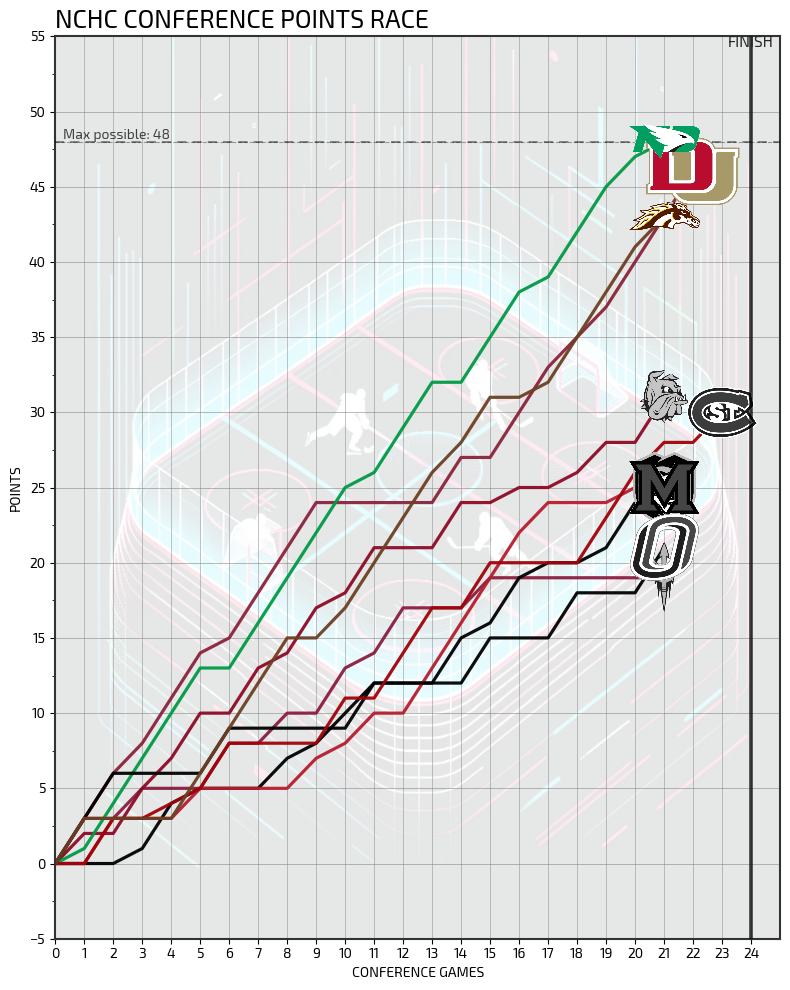

In [73]:
## Create Plots for Each Conference
ts_df = build_conference_points_time_series(team_games_df)

#### CALL NEW FUNCTION
fig, ax = plot_conference_points_race(
    ts_df,
    conf_name="NCHC",
    team_color_mapping=config.team_color_mapping,
    logo_mapping=logo_mapping,
    logo_folder=logo_folder,
    background_img_path=background_img_path2,
    highlight_teams=["Boston University"],
    figsize=(8, 10),
    y_mode="points",
    conf_games_scheduled=conf_games_scheduled,  # <-- ADD THIS
)

# END NEW CODE